# 기초통계 과제: DailyBox 마케팅 전략 분석 (템플릿)

`marketing_assignment_instructions.md`의 문항 번호에 맞춰 빈칸(`____`)을 채우고, 마크다운 셀에 해석/결론을 서술하세요. 여러분은 DailyBox 전략팀 분석가입니다.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.outliers_influence import variance_inflation_factor

plt.rcParams['font.family'] = 'Malgun Gothic'   # Windows는 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')

df = pd.read_csv('marketing_customers.csv')
df.head()

,customer_id,age,gender,signup_channel,membership_tier,monthly_visits,avg_discount_rate,online_ad_cost,offline_ad_cost,total_ad_cost,campaign_group,responded,monthly_spend
0,1,21,Female,Organic Search,Basic,10,0.140,16.56,0.34,16.90,control,0,35.10
1,2,47,Female,Referral,Silver,7,0.037,7.45,8.00,15.45,treatment,0,55.42
2,3,42,Female,Social Ads,Silver,8,0.347,20.54,6.92,27.46,treatment,1,86.58
3,4,27,Female,Referral,Silver,5,0.269,9.98,2.80,12.78,control,0,20.63
4,5,26,Female,Social Ads,Basic,13,0.157,6.83,0.57,7.40,treatment,1,25.43


## Part 1. 고객 이해 (EDA)

**1. 데이터 로드 및 구조 확인**

In [4]:
print(df.shape)
print(df.dtypes)
print(df.describe())
print(df.isna().sum())

(6000, 13)
customer_id            int64
age                    int64
gender                   str
signup_channel           str
membership_tier          str
monthly_visits         int64
avg_discount_rate    float64
online_ad_cost       float64
offline_ad_cost      float64
total_ad_cost        float64
campaign_group           str
responded              int64
monthly_spend        float64
dtype: object
       customer_id          age  monthly_visits  avg_discount_rate  \
count  6000.000000  6000.000000     6000.000000        6000.000000   
mean   3000.500000    40.263333        8.201500           0.171374   
std    1732.195139    11.513402        4.221437           0.096024   
min       1.000000    18.000000        1.000000           0.000000   
25%    1500.750000    32.000000        5.000000           0.098000   
50%    3000.500000    40.000000        8.000000           0.158000   
75%    4500.250000    48.000000       11.000000           0.233250   
max    6000.000000    78.000000       

> ✍️ 고객 규모와 주요 수치 변수 범위를 한두 줄로 요약하세요.

데이터는 6000명 고객과 13개 변수러 이루어져 있다.

age: 18-78

monthly_visits: 1-34

avg_discount_rate: 0-0.5

online_ad_cost: 0.05-65.31

offline_ad_cost: 0-39.38

total_ad_cost: 0.59-68.28

monthly_spend: 8.26-288.44

**2. 매출 분포와 로그변환** — monthly_spend 왜도 계산 + log1p 전/후 비교

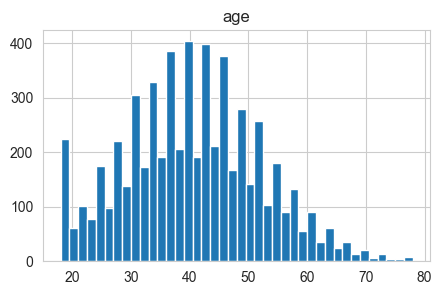

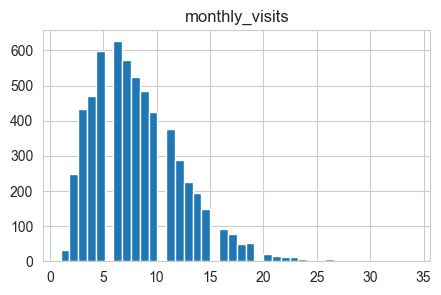

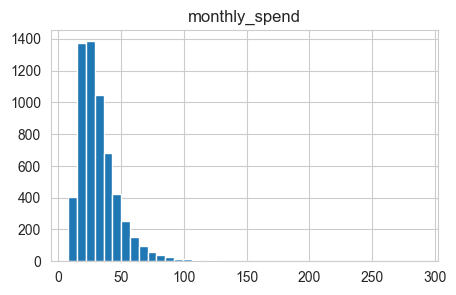

왜도 = 2.5456526289788064


c:\Users\user\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


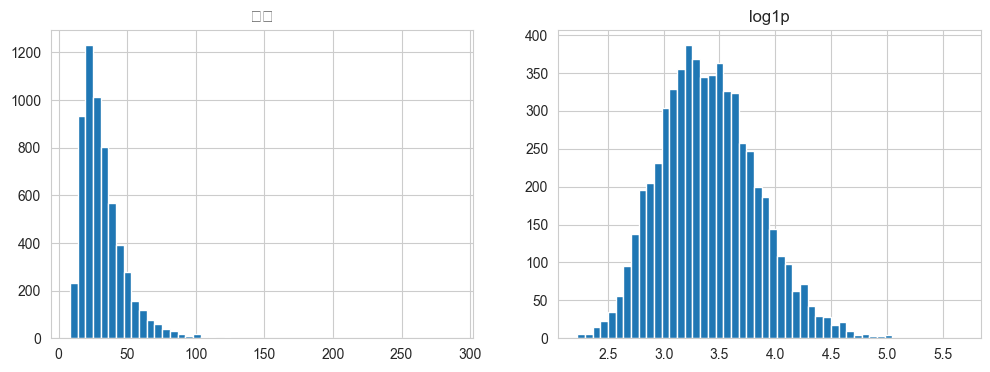

In [5]:
for col in ['age', 'monthly_visits', 'monthly_spend']:
    plt.figure(figsize=(5, 3))
    plt.hist(df[col], bins=40)
    plt.title(col); plt.show()

skew = df['monthly_spend'].skew()   # 힌트: 왜도 메서드
print('왜도 =', skew)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['monthly_spend'], bins=50);          axes[0].set_title('원본')
axes[1].hist(np.log1p(df['monthly_spend']), bins=50)
axes[1].set_title('log1p'); plt.show()

> ✍️ 매출 분포가 왜 치우쳐 있는지, 로그변환이 왜 도움이 되는지 서술하세요.

대부분 고객은 낮거나 중간 수준의 구매 수준을 보이지만, 일부 고객이 매우 큰 구매를 하여 치우친 분포가 나타난다. 로그 변환 시에는 이 왜도가 감소하여 분포가 대칭적인 형태가 나타난다. 이처럼 로그 변환은 정규성을 복원하고 이상치 영향을 줄이는 데에 도움이 된다.


**3. 채널·등급별 매출 Boxplot**

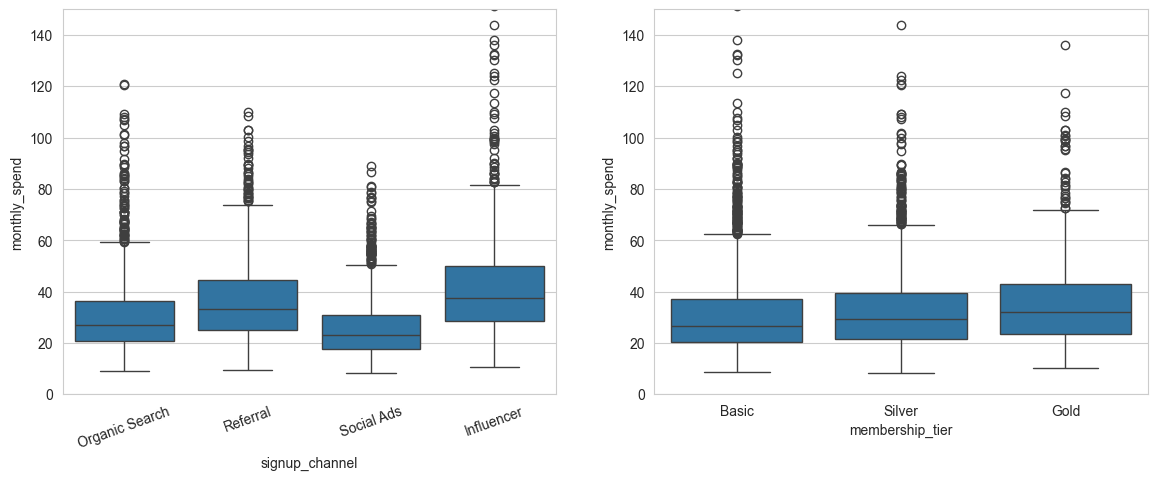

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='signup_channel', y='monthly_spend', ax=axes[0])
axes[0].set_ylim(0, 150); axes[0].tick_params(axis='x', rotation=20)
sns.boxplot(data=df, x='membership_tier', y='monthly_spend',    # 힌트: 'membership_tier'
            order=['Basic', 'Silver', 'Gold'], ax=axes[1])
axes[1].set_ylim(0, 150); plt.show()

> ✍️ 어떤 채널/등급이 고가치 고객으로 보이는지 해석하세요.

Influencer 채널과 Gold 등급이 가장 고가치로 보인다.

## Part 2. 가정 확인

**4. 1종/2종 오류 (개념)**

> ✍️ "쿠폰 캠페인은 효과가 없다"는 H0에 대해 1종 오류와 2종 오류가 각각 무엇을 의미하고, 어떤 손실을 끼치는지 서술하세요.

1종 오류: 실제 쿠폰 캠페인에 매출 효과가 없는데 있다고 판단. 이 때 회사는 실효도 없는 쿠폰을 발행하며 비용을 낭비한다.

2종 오류: 실제 캠페인에 효과가 있는데 없다고 판단. 이 때 효과적인 캠페인을 중단하며 손수 기회를 잃는다.

**5. 정규성 검정 (Shapiro-Wilk) — 원본 vs 로그**

c:\Users\user\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


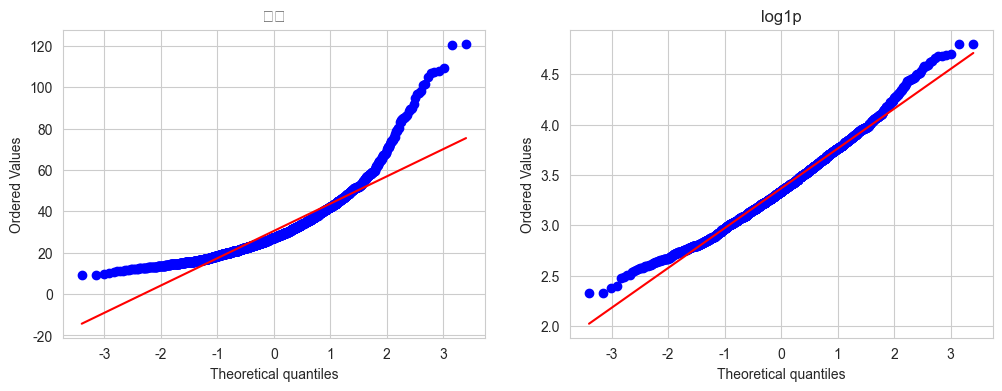

원본   ShapiroResult(statistic=np.float64(0.8534533976380867), pvalue=np.float64(3.631642400263992e-21))
log1p  ShapiroResult(statistic=np.float64(0.9873230180962407), pvalue=np.float64(0.00024486116128267225))


In [7]:
x = df.loc[df.signup_channel == 'Organic Search', 'monthly_spend']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
stats.probplot(x, dist='norm', plot=axes[0]);            axes[0].set_title('원본')
stats.probplot(np.log1p(x), dist='norm', plot=axes[1]);  axes[1].set_title('log1p')
plt.show()

xs = x.sample(500, random_state=0)
print('원본  ', stats.shapiro(xs))          # 힌트: shapiro
print('log1p ', stats.shapiro(np.log1p(xs)))

> ✍️ 가설을 세우고, 두 결과를 0.05 기준으로 비교 해석하세요.

가설로 정규성을 가정하자. 원본 p-value는 3.63e-21으로 0.05보다 작아 귀무가설을 기각한다. 즉 정규성을 따르지 않는다. 또한, 로그변환 후 p-value도 약 2.4e-4으로 0.05보다 작아 똑같이 정규성을 만족하지 않는다는 것을 알 수 있다.

**6. 등분산성 검정**

In [8]:
groups = [g['monthly_spend'].values for _, g in df.groupby('signup_channel')]
stat, p = stats.levene(*groups)
print('Levene p =', p)

Levene p = 4.335927248189437e-44


> ✍️ p값을 0.05 기준으로 해석하고, ANOVA에 어떤 의미인지 서술하세요.

귀무가설로 네 채널의 분산이 같다고 하자. 이 때, p-value는 4.33e-44으로 0.05보다 작아 귀무가설은 기각된다. ANOVA는 등분산 가정이 필요하므로, ANOVA의 결과 해석이 어려워질 위험이 있다.

## Part 3. 집단 비교 검정

**7. 쿠폰 캠페인 효과 검증 — 두 집단 평균 비교 (Welch's t-test)**

In [9]:
ctrl = df.loc[df.campaign_group == 'control', 'monthly_spend']
trt  = df.loc[df.campaign_group == 'treatment', 'monthly_spend']
print('평균', ctrl.mean(), trt.mean())

print('Levene p =', stats.levene(ctrl, trt).pvalue)
# 등분산이 깨지면 equal_var=False (Welch)
t, p = stats.ttest_ind(ctrl, trt, equal_var=False)
print('t=%.2f p=%.3g' % (t, p))

평균 29.707517635203224 34.80327820046312
Levene p = 1.1644920921295873e-19
t=-11.88 p=3.86e-32


> ✍️ H0/H1을 명시하고, 캠페인을 지속할지 결론 내리세요.

H0: treatment/control의 평균 월 구매액은 같다.

H1: 두 집단의 평균 월 구매액은 다르다.

우선 유의수준 0.05으로 잡아도 Levene p는 그보다 작으므로 등분산성이 없어 Welch's t-test를 사용한다. 이 검정 아래에서 p=3.86e-32으로 유의수준보다 낮아 H0를 기각한다.
쿠폰을 받은 집단의 평균 월 구매액은 우선 받지 않은 집단보다 약 5.10 높은 것으로 확인된다. 무작위 고객을 추출한 것이므로 이 효과는 캠페인을 지속할 근거가 된다.

**8. 채널 비교 — One-way ANOVA + Tukey HSD**

In [10]:
F, p = stats.f_oneway(*groups)
print('ANOVA F=%.2f p=%.3g' % (F, p))

tukey = pairwise_tukeyhsd(df['monthly_spend'], df['signup_channel'], alpha=0.05)
print(tukey)

ANOVA F=276.85 p=2.67e-168
         Multiple Comparison of Means - Tukey HSD, FWER=0.05         
    group1         group2     meandiff p-adj  lower    upper   reject
---------------------------------------------------------------------
    Influencer Organic Search -12.3582   0.0 -13.9696 -10.7469   True
    Influencer       Referral  -6.1796   0.0  -7.9507  -4.4086   True
    Influencer     Social Ads -17.0177   0.0 -18.6659 -15.3696   True
Organic Search       Referral   6.1786   0.0    4.716   7.6412   True
Organic Search     Social Ads  -4.6595   0.0  -5.9706  -3.3484   True
      Referral     Social Ads -10.8381   0.0 -12.3412   -9.335   True
---------------------------------------------------------------------


> ✍️ 가설을 세우고, 어느 채널이 유의하게 고가치/저가치인지 결론지으세요.

H0: 네 채널의 평균 월 구매액은 같다.

H1: 적어도 한 채널의 평균 월 구매액은 다르다.

ANOVA의 p-value가 2.67e-168이므로, 유의수준 0.05를 상정할 때 H0를 기각할 수 있다. Tukey HSDD 결과에서도 모든 채널 쌍에서 차이가 드러난다.
평균 구매액 차를 고려하고 위의 Box Plot 결과를 참조할 때, Influencer 그룹이 가장 높은 가치의 고객을, Social Ads 그룹이 가장 낮은 가치의 고객을 유입한다.

**9. 교호작용 — Two-way ANOVA (선택 심화)**

In [11]:
model = smf.ols('monthly_spend ~ C(signup_channel) * C(campaign_group)', data=df).fit()
print(sm.stats.anova_lm(model, typ=2))

                                           sum_sq      df           F  \
C(signup_channel)                    2.069851e+05     3.0  284.971525   
C(campaign_group)                    3.868639e+04     1.0  159.787112   
C(signup_channel):C(campaign_group)  6.749231e+03     3.0    9.292159   
Residual                             1.450735e+06  5992.0         NaN   

                                            PR(>F)  
C(signup_channel)                    6.336934e-173  
C(campaign_group)                     3.634363e-36  
C(signup_channel):C(campaign_group)   3.973329e-06  
Residual                                       NaN  


> ✍️ 각 주효과와 교호작용의 유의성을 해석하세요.

채널, 캠페인의 주효과 모두 p-value가 유의수준 0.05보다 작으니 모두 유입 채널 월 구매액에 유의미한 영향이 있음을 알 수 있다. 교호작용의 p-value도 똑같이 0.05보다 작아 유의하다.

## Part 4. 회귀분석

**10. 단순선형회귀 & 다중회귀**

In [12]:
# 단순
m1 = smf.ols('monthly_spend ~ monthly_visits', data=df).fit()
print(m1.summary().tables[1]); print('R2 =', m1.rsquared)

                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         24.6737      0.462     53.357      0.000      23.767      25.580
monthly_visits     0.9268      0.050     18.487      0.000       0.829       1.025
R2 = 0.0539092756305285


In [13]:
# 다중 (범주형은 C()로 더미코딩)
m2 = smf.ols(
    'monthly_spend ~ monthly_visits + avg_discount_rate + online_ad_cost '
    '+ C(signup_channel) + C(gender)', data=df).fit()     #
print(m2.summary())
print('단순 adjR2=%.4f / 다중 adjR2=%.4f' % (m1.rsquared_adj, m2.rsquared_adj))

                            OLS Regression Results                            
Dep. Variable:          monthly_spend   R-squared:                       0.218
Model:                            OLS   Adj. R-squared:                  0.217
Method:                 Least Squares   F-statistic:                     238.3
Date:                Tue, 21 Jul 2026   Prob (F-statistic):          9.35e-314
Time:                        23:58:50   Log-Likelihood:                -24723.
No. Observations:                6000   AIC:                         4.946e+04
Df Residuals:                    5992   BIC:                         4.952e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In

> ✍️ 방문·할인·광고비 중 매출에 실제로 기여하는 레버는? 할인 확대는 좋은 전략인가? 채널 계수는 어떻게 해석되나?

단순회귀에서 월 방문 횟수는 0.927, 다중회귀에서도 방문 횟수는 0.917의 계수를 갖는다. 즉 방문 1회 당 월 구매액이 그 수준으로 오름을 알 수 있으니 방문 횟수가 실제로 기여하는 레버임을 알 수 있다.

평균 할인율의 계수가 11.423임에서 미루어 보아, 할인율이 10% 증가하면 구매액은 1.142 증가한다. 이는 구매액 증대에 있어서는 좋은 전략이지만, 할인 확대 자체의 비용을 감안하여 전략의 좋고 나쁨을 면밀히 판단해야 한다.

채널 계수를 통한 효과를 해석해보면, Influencer의 효과가 가장 높고, 다음으로 Referral, Organic Search, 마지막으로 Social Ads의 순서이다.

**11. 다중공선성 / VIF** — online + offline + total 모두 넣기

In [14]:
def vif_table(X):
    X = sm.add_constant(X)
    return pd.DataFrame({'feature': X.columns,
        'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]})

X_bad = df[['monthly_visits', 'online_ad_cost', 'offline_ad_cost', 'total_ad_cost']]
print(vif_table(X_bad))

X_ok = df[['monthly_visits', 'online_ad_cost', 'offline_ad_cost']]  # total 제거
print(vif_table(X_ok))

           feature       VIF
0            const  8.212525
1   monthly_visits  1.000060
2   online_ad_cost       inf
3  offline_ad_cost       inf
4    total_ad_cost       inf
           feature       VIF
0            const  8.212525
1   monthly_visits  1.000060
2   online_ad_cost  1.000251
3  offline_ad_cost  1.000213


c:\Users\user\miniforge3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


> ✍️ VIF에 어떤 문제가 있고 왜 그런지(total=online+offline), 어떻게 해결하는지 서술하세요.

online/offline/total의 광고 비용을 함께 넣으면 VIF가 inf로 나타난다. 이는 total=online+offline의 선형 관계에 의해 선형관계가 존재하므로 발생한다.
따라서 total과 그 세부(online/offline) 과고비를 동시에 사용해선 안 되고, 분석 목적에 따라 total 또는 online/offline을 선택해야 한다.

**12. 잔차 진단** (+ 로그변환 비교)

c:\Users\user\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51092 (\N{HANGUL SYLLABLE JAN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\minifor

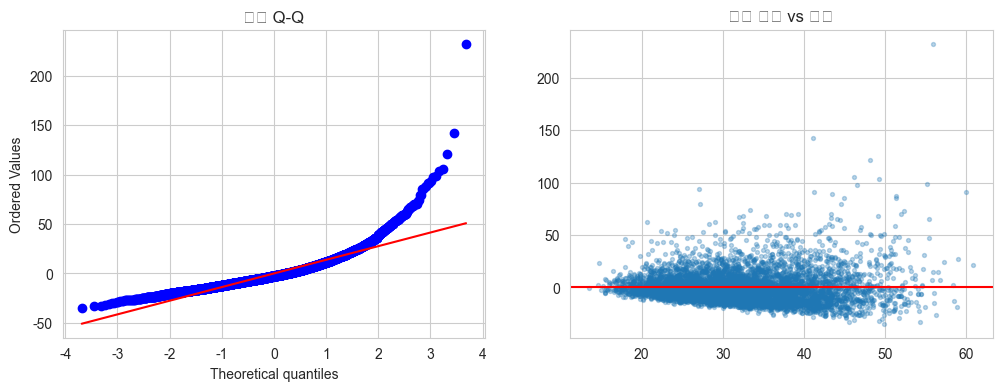

c:\Users\user\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51092 (\N{HANGUL SYLLABLE JAN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


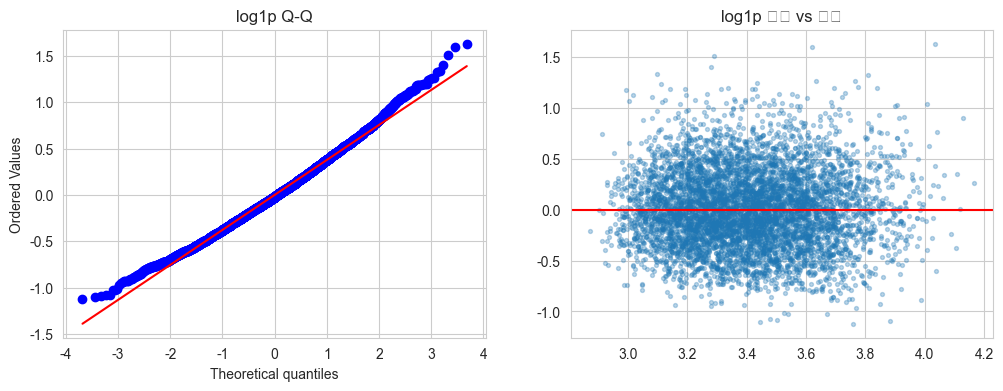

In [15]:
def resid_plots(model, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    stats.probplot(model.resid, dist='norm', plot=axes[0]); axes[0].set_title(title+' Q-Q')
    axes[1].scatter(model.fittedvalues, model.resid, s=8, alpha=0.3)
    axes[1].axhline(0, color='red'); axes[1].set_title(title+' 잔차 vs 예측')
    plt.show()

resid_plots(m2, '원본')

m2_log = smf.ols('np.log1p(monthly_spend) ~ monthly_visits + avg_discount_rate '
                 '+ online_ad_cost + C(signup_channel) + C(gender)', data=df).fit()
resid_plots(m2_log, 'log1p')

> ✍️ 원본 대비 로그변환 모형의 잔차가 어떻게 개선되는지 서술하세요.

원본의 Q-Q plot에서는 꼬리가 직선에서 벗어나 잔차의 정규성이 좋지 않다. 산점도 또한 일정하게 퍼져있지 않아 이분산성을 의심해볼 수 있다.

로그변환 모형에서는 Q-Q plot이 직선에 더 가까워지고 잔차의 퍼짐도 감소해 정규성, 등분산성이 개선된다.


## Part 5. 타겟팅 (로지스틱 회귀)

**13~14. 로지스틱 회귀 & 오즈비 해석**

In [16]:
logit = smf.logit(
    'responded ~ age + monthly_visits + C(campaign_group) + C(membership_tier) '
    '+ C(signup_channel)', data=df).fit()
print(logit.summary())

odds = pd.DataFrame({'coef': logit.params, 'p': logit.pvalues,
                     'odds_ratio': np.exp(logit.params)})
print(odds.round(3))

Optimization terminated successfully.
         Current function value: 0.512887
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:              responded   No. Observations:                 6000
Model:                          Logit   Df Residuals:                     5991
Method:                           MLE   Df Model:                            8
Date:                Tue, 21 Jul 2026   Pseudo R-squ.:                 0.06405
Time:                        23:58:50   Log-Likelihood:                -3077.3
converged:                       True   LL-Null:                       -3287.9
Covariance Type:            nonrobust   LLR p-value:                 5.453e-86
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Intercept                              -2.2301      0.157 

> ✍️ 쿠폰 발송·멤버십 등급의 오즈비를 해석하고, 다음 캠페인 타겟 세그먼트를 정하세요.

로지스틱 회귀 결과, 모든 설명 변수가 모두 유의수준 0.05에서 통계적으로 유의하다. 쿠폰 발송군과 미발손군의 반응 오즈비는 2.43배이고, Gold와 Basic의 반응 오즈비는 2.02배, Silver에 대해서는 1.41배엿다.


채널 기준으로의 범주를 Influencer로 할 때, 다른 세 채널의 오즈비는 1보다 작아 Influencer의 반응 가능성이 가장 높다고 할 수 있다.

따라서 다음 캠페인은 influencer 채널에서 유입된 Gold 회원 중 방문 빈도가 가장 높은 고객을 타겟으로 하는 것이 가장 적절하다.

## 종합 결론 — CMO 보고용 마케팅 전략

> ✍️ Part 1~5를 종합해 (1) 캠페인 지속 여부 (2) 채널 예산 배분 (3) 매출 레버 (4) 타겟팅 (5) 분석 한계를 담은 한 장짜리 전략을 서술하세요. (report.pdf의 핵심)

(1) 캠페인 지속 여부:
쿠폰 발송군의 평균 매출 34.8, 미발송군 29.7로 쿠폰 발송군이 더욱 높아 캠페인은 지속하는 것이 좋다.

(2) 채널 예산 배분:
채널별 고객 가치는 Influencer, Referral, Organic Search, Social Ads 순으로 높다. 그러므로 그 순서에 알맞게(Influencer에 더 높게) 예산을 배분하는 것이 좋다.

(3) 매출 레버:
방문 횟수와 온라인 광고비는 매출과 양의 관계에 있어 안정적인 레버임을 보였다. 그러므로 방문 유도에 우선 투자한다.

(4) 타겟팅:
쿠폰 반응 가능성은 Gold 등급이며 Influencer 유입에서 가장 높았다. 이 고객군을 가장 먼저 타겟팅한다.

(5) 분석 한계:
캠페인 결과 이외의 분석은 인과관계로 판단해선 안 되고, 연관성이 있다 정도로만 해석해야 한다.